<h1>RESPON MODUL 3

<h3>IMPORT LIBRARY

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

<h3>MEMBUAT FUNGSI RGB & GRAYSCALE

In [2]:
def rgb(img) :
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def gray(img) :
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

<h3>TAMPILKAN CITRA AWAL & GRAYSCALE

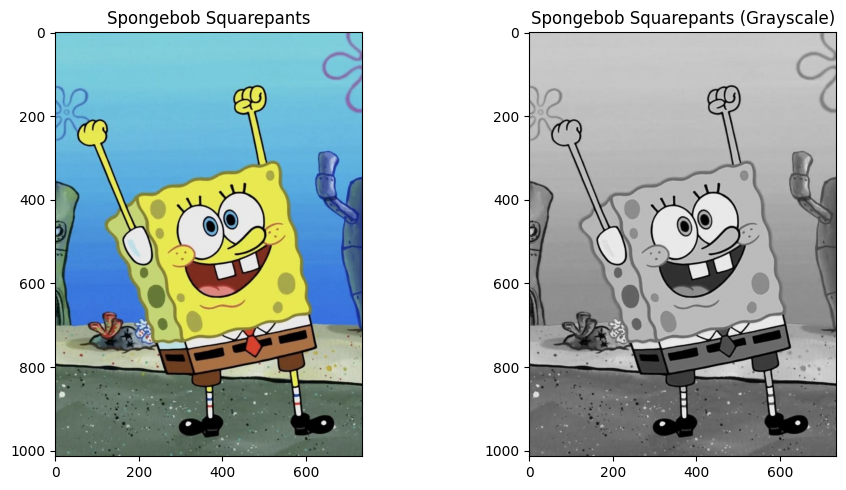

In [5]:
sponge = plt.imread('Assets/Spongebob.jpeg')
sponge_gray = gray(sponge)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(sponge)
plt.title("Spongebob Squarepants")

plt.subplot(1,2,2)
plt.imshow(sponge_gray, cmap='gray')
plt.title("Spongebob Squarepants (Grayscale)")

plt.tight_layout()
plt.show()

<h3>FUNGSI FILTERING

In [9]:
def filtering(img, size, mode):

    h, w = img.shape

    pad = size // 2

    padded = np.pad(img, pad, mode='edge')

    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:

        case 'mean':

            area = size * size

            for i in range(h):
                for j in range(w):

                    region = padded[i:i+size, j:j+size]

                    canvas[i, j] = np.sum(region) / area

        case 'median':

            for i in range(h):
                for j in range(w):

                    region = padded[i:i+size, j:j+size]

                    canvas[i, j] = np.median(region)

        case 'modus':

            for i in range(h):
                for j in range(w):

                    region = padded[i:i+size, j:j+size]

                    nilai, jumlah = np.unique(region, return_counts=True)

                    canvas[i, j] = nilai[np.argmax(jumlah)]

    return canvas

<h3>FUNGSI KONVOLUSI

In [7]:
def convolution(img, kernel):
    size = kernel.shape[0]

    pad_size = size // 2

    padded = np.pad(img, pad_size, mode='constant')

    canvas = np.zeros_like(img).astype(np.float32)

    h, w = img.shape

    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)

    return canvas

<h3>KERNEL SMOOTHING & SHARPENING

In [8]:
kernelSmoothing = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

kernelSharpening = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

<h3>PERSIAPAN CITRA AWAL DENGAN MEDIAN FILTER

<p align=justify>Dari beberapa percobaan filtering, median filter memberikan hasil paling baik untuk proses edge detection pada gambar SpongeBob. Median filter mampu mengurangi noise tanpa menghilangkan garis tepi utama pada objek.

Hal ini terjadi karena median filter tidak melakukan perataan berlebihan seperti mean filter, sehingga outline hitam pada karakter tetap terlihat jelas.

Kernel 3×3 dipilih karena cukup untuk mengurangi noise ringan tanpa membuat gambar menjadi terlalu blur.

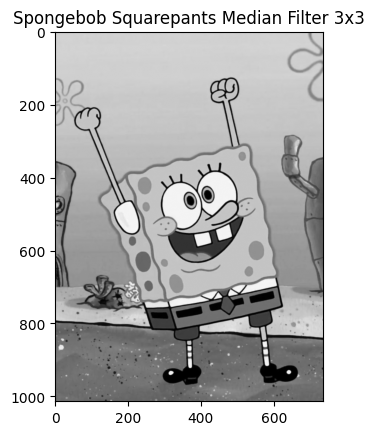

In [12]:
filtered = filtering(sponge_gray, 3, 'median')

plt.imshow(filtered, cmap='gray')
plt.title("Spongebob Squarepants Median Filter 3x3")
plt.show()

<h3>FUNGSI DETEKSI TEPI

In [13]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)

    canvas = np.zeros_like(img, dtype=np.float32)

    canvas = np.abs(gx) + np.abs(gy)

    canvas = canvas * 255 / np.max(canvas)

    return np.clip(canvas, 0, 255).astype(np.uint8)

<h3>KERNEL SOBEL

In [14]:
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
])

<h3>DETEKSI TEPI DENGAN SOBEL

In [17]:
hasil_sobel = edge(
    filtered,
    sobelX,
    sobelY
)

<p align=justify>Setelah filtering selesai, tahap berikutnya adalah deteksi tepi (edge detection). Tujuan dari edge detection adalah menemukan perubahan intensitas piksel yang signifikan pada citra. Perubahan intensitas tersebut biasanya menunjukkan batas suatu objek.

Metode Sobel dipilih karena menghasilkan edge yang lebih stabil dan lebih tahan terhadap noise dibandingkan operator lain seperti Prewitt dan Roberts.

<h3>TAMPILKAN HASIL

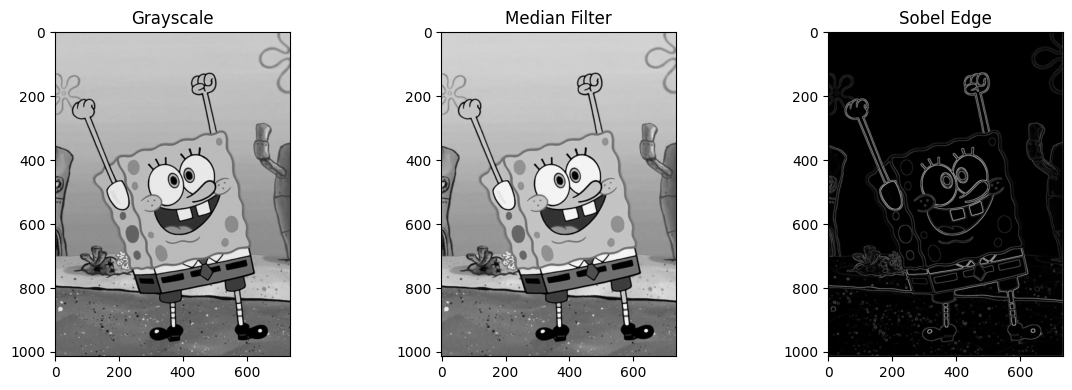

In [19]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(sponge_gray, cmap='gray')
plt.title('Grayscale')

plt.subplot(1,3,2)
plt.imshow(filtered, cmap='gray')
plt.title('Median Filter')

plt.subplot(1,3,3)
plt.imshow(hasil_sobel, cmap='gray')
plt.title('Sobel Edge')

plt.tight_layout()
plt.show()